# Text-line detection playground (PaddleOCR → crop → VietOCR)

Notebook này copy lại phần **Step 2+ (detect + crop)** trong `notebooks/05_crawl_and_detect_CLEANED.ipynb` và chỉnh nhẹ để chạy trên ảnh trong `tests/test/`.

Mục tiêu: bạn có thể **nhìn trực tiếp bbox/crops**, chỉnh tham số, và iterate nhanh trước khi mang fix vào project chính.


In [1]:
from __future__ import annotations

import os
from pathlib import Path

import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Root + folders
ROOT = Path('.').resolve()
TEST_DIR = ROOT / 'tests' / 'test'
OUT_DIR = ROOT / 'tests' / 'output' / 'notebook_detection'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('ROOT   :', ROOT)
print('TEST_DIR:', TEST_DIR)
print('OUT_DIR :', OUT_DIR)
assert TEST_DIR.exists(), f"Missing {TEST_DIR}"

ROOT   : /home/khang/Projects/OCR_project/ocr_ai_agent_coding
TEST_DIR: /home/khang/Projects/OCR_project/ocr_ai_agent_coding/tests/test
OUT_DIR : /home/khang/Projects/OCR_project/ocr_ai_agent_coding/tests/output/notebook_detection


In [2]:
# ---- Constants (mirrors notebook/05 Step2+) ----

MAX_SIDE = 1600
MIN_LINE_H = 14
MIN_LINE_W = 60

MIN_TEXT_LENGTH = 2
MIN_TEXT_LENGTH_FILTER = 6

# Runtime knobs
USE_GPU = True   # set False nếu máy không có CUDA / paddle không support
BATCH_SIZE = 32

# Detector thresholds (quan trọng để tăng/giảm số bbox)
DET_DB_THRESH = 0.30
DET_DB_BOX_THRESH = 0.20
DET_DB_UNCLIP_RATIO = 2.0


In [3]:
# ---- Step 2: Initialize OCR Models (copied from notebook/05) ----
from paddleocr import PaddleOCR

try:
    ocr = PaddleOCR(
        use_angle_cls=False,
        lang='vi',
        use_det=True,
        use_gpu=USE_GPU,
        use_rec=False,
        det_limit_side_len=MAX_SIDE,
        det_limit_type='max',
        det_db_thresh=DET_DB_THRESH,
        det_db_box_thresh=DET_DB_BOX_THRESH,
        det_db_unclip_ratio=DET_DB_UNCLIP_RATIO,
        show_log=False,
        enable_mkldnn=True,
    )
    print('✓ PaddleOCR detector initialized (use_gpu=%s)' % USE_GPU)
except Exception as e:
    print('PaddleOCR init failed with use_gpu=%s:' % USE_GPU, e)
    print('→ fallback: init PaddleOCR with use_gpu=False')
    USE_GPU = False
    ocr = PaddleOCR(
        use_angle_cls=False,
        lang='vi',
        use_det=True,
        use_gpu=False,
        use_rec=False,
        det_limit_side_len=MAX_SIDE,
        det_limit_type='max',
        det_db_thresh=DET_DB_THRESH,
        det_db_box_thresh=DET_DB_BOX_THRESH,
        det_db_unclip_ratio=DET_DB_UNCLIP_RATIO,
        show_log=False,
        enable_mkldnn=True,
    )
    print('✓ PaddleOCR detector initialized (use_gpu=False)')


✓ PaddleOCR detector initialized (use_gpu=True)


In [4]:
# ---- Step 2: Initialize VietOCR recognizer (copied from notebook/05) ----
from vietocr.tool.predictor import Predictor
from vietocr.tool.config import Cfg

config = Cfg.load_config_from_name('vgg_transformer')
config['cnn']['pretrained'] = True
config['predictor']['beamsearch'] = True

# device string: đổi thành 'cpu' nếu không có GPU
config['device'] = 'cuda:0' if USE_GPU else 'cpu'
try:
    recognitor = Predictor(config)
    print('✓ VietOCR recognizer initialized on', config['device'])
except Exception as e:
    print('VietOCR init failed on', config['device'], ':', e)
    print('→ fallback: init VietOCR on cpu')
    config['device'] = 'cpu'
    recognitor = Predictor(config)
    print('✓ VietOCR recognizer initialized on', config['device'])


18533it [11:37, 26.57it/s] 


✓ VietOCR recognizer initialized on cuda:0


## Helper functions (from notebook/05 Step3)

- đọc ảnh + resize nhanh
- upscale ảnh nhỏ
- sharpen để detector bắt nét hơn
- safe wrapper cho `ocr.ocr(img)`


In [5]:
def read_and_resize_fast(path: str, max_side: int = MAX_SIDE):
    """Read and resize image efficiently."""
    # cv2.imread trong Linux thường OK với unicode; nếu bạn gặp lỗi, có thể chuyển sang imdecode.
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        return None
    h, w = img.shape[:2]
    m = max(h, w)
    if m > max_side:
        scale = max_side / m
        img = cv2.resize(img, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_AREA)
    return img


def upscale_if_small(img, min_side=800, max_scale=2.0):
    """Upscale small images for better detection."""
    h, w = img.shape[:2]
    m = max(h, w)
    if m < min_side:
        scale = min(min_side / m, max_scale)
        img = cv2.resize(img, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_CUBIC)
    return img


def sharpen(img):
    """Sharpen image for better OCR."""
    kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
    return cv2.filter2D(img, -1, kernel)


def safe_ocr(detector, img):
    """Safe OCR with error handling."""
    if detector is None:
        return []
    try:
        result = detector.ocr(img)
    except Exception as e:
        print(f"OCR error: {e}")
        return []
    if not result or result[0] is None:
        return []
    return result[0]


## Cropping utils (from notebook/05 Step3)

PaddleOCR trả polygon 4 điểm. Ta:
- order points
- perspective warp để lấy line crop
- auto-rotate nếu crop bị dọc


In [6]:
def order_points(pts: np.ndarray) -> np.ndarray:
    """Order 4 points clockwise from top-left."""
    rect = np.zeros((4, 2), dtype='float32')
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]  # top-left
    rect[2] = pts[np.argmax(s)]  # bottom-right
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]  # top-right
    rect[3] = pts[np.argmax(diff)]  # bottom-left
    return rect


def crop_rotated(img: np.ndarray, box: np.ndarray) -> np.ndarray | None:
    """Crop rotated bounding box using perspective transform."""
    box = box.astype('float32')
    w1 = np.linalg.norm(box[0] - box[1])
    w2 = np.linalg.norm(box[2] - box[3])
    width = int(max(w1, w2))
    h1 = np.linalg.norm(box[0] - box[3])
    h2 = np.linalg.norm(box[1] - box[2])
    height = int(max(h1, h2))
    if width <= 0 or height <= 0:
        return None
    dst = np.array(
        [[0, 0], [width - 1, 0], [width - 1, height - 1], [0, height - 1]],
        dtype='float32',
    )
    M = cv2.getPerspectiveTransform(box, dst)
    warped = cv2.warpPerspective(img, M, (width, height))
    return warped


## Detection + crop + VietOCR batch recognition (from notebook/05 Step4)

Cell này giữ nguyên logic chính của notebook:
- detect polygons bằng PaddleOCR
- crop từng polygon
- resize height=32 + PIL RGB
- `recognitor.predict_batch(...)`

Ghi chú: filter `is_valid_vietnamese_text` trong notebook gốc khá strict (bắt buộc có dấu). Ở đây mình để **optional** để bạn debug crop/recognition trước.


In [7]:
def is_valid_vietnamese_text(text: str, min_length: int = 2) -> bool:
    """Validate Vietnamese-ish text (copied from notebook/05, but keep it optional in main loop)."""
    if not text or len(text.strip()) < min_length:
        return False

    text_no_space = text.strip()

    VIETNAMESE_CHARS = set(config['vocab'])
    valid_char_count = sum(1 for c in text_no_space if c in VIETNAMESE_CHARS)
    valid_ratio = valid_char_count / len(text_no_space) if len(text_no_space) > 0 else 0
    if valid_ratio < 0.8:
        return False

    vietnamese_diacritics = 'àảãáạăằẳẵắặâầẩẫấậèẻẽéẹêềểễếệìỉĩíịòỏõóọôồổỗốộơờởỡớợùủũúụưừửữứựỳỷỹýỵđ'
    has_diacritics = any(c in vietnamese_diacritics for c in text.lower())
    if not has_diacritics:
        return False

    letters_only = [c for c in text_no_space if c.isalpha()]
    if letters_only:
        uppercase_ratio = sum(1 for c in letters_only if c.isupper()) / len(letters_only)
        if uppercase_ratio > 0.9 and not has_diacritics:
            return False

    return True


def crop_text_lines_with_recognition(
    image_path: str,
    detector,
    recognitor,
    out_dir: str,
    min_line_h: int = MIN_LINE_H,
    min_line_w: int = MIN_LINE_W,
    max_side: int = MAX_SIDE,
    min_text_length: int = MIN_TEXT_LENGTH,
    min_text_length_filter: int = MIN_TEXT_LENGTH_FILTER,
    batch_size: int = BATCH_SIZE,
    enable_vietnamese_filter: bool = False,
):
    """Detect, recognize, and crop text lines with batch processing."""
    img = read_and_resize_fast(image_path, max_side)
    if img is None:
        return [], [], [], None

    img = upscale_if_small(img, min_side=800)
    img = sharpen(img)

    lines = safe_ocr(detector, img)
    if len(lines) == 0:
        return [], [], [], img

    dt_polys = [np.array(r[0], dtype=np.float32) for r in lines]
    Path(out_dir).mkdir(parents=True, exist_ok=True)

    valid_crops = []
    rejected_crops = []
    recognition_results = []
    fname_base = Path(image_path).stem

    # Prepare all crops first
    cropped_images: list[tuple[np.ndarray, Image.Image]] = []
    valid_boxes: list[np.ndarray] = []
    box_indices: list[int] = []

    for i, box in enumerate(dt_polys):
        try:
            box = order_points(box)
            cropped_img = crop_rotated(img, box)
            if cropped_img is None or cropped_img.size == 0:
                rejected_crops.append({'reason': 'empty_crop', 'box': box.tolist()})
                continue

            h, w = cropped_img.shape[:2]
            if h < min_line_h or w < min_line_w:
                rejected_crops.append({'reason': 'too_small', 'box': box.tolist(), 'h': int(h), 'w': int(w)})
                continue

            # Auto-rotate if vertical
            if h > w:
                cropped_img = cv2.rotate(cropped_img, cv2.ROTATE_90_CLOCKWISE)
                h, w = cropped_img.shape[:2]

            # Small fixed padding (notebook gốc)
            pad = 2
            cropped_img = cv2.copyMakeBorder(
                cropped_img,
                pad,
                pad,
                pad,
                pad,
                cv2.BORDER_CONSTANT,
                value=[255, 255, 255],
            )

            # Resize for VietOCR (height=32)
            target_h = 32
            ratio = cropped_img.shape[1] / max(1, cropped_img.shape[0])
            target_w = int(target_h * ratio)
            if target_w <= 1:
                rejected_crops.append({'reason': 'invalid_resize', 'box': box.tolist()})
                continue

            resized = cv2.resize(cropped_img, (target_w, target_h), interpolation=cv2.INTER_CUBIC)
            cropped_pil = Image.fromarray(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))

            cropped_images.append((resized, cropped_pil))
            valid_boxes.append(box)
            box_indices.append(i)

        except Exception as e:
            rejected_crops.append(
                {
                    'reason': f'error: {str(e)}',
                    'box': box.tolist() if isinstance(box, np.ndarray) else None,
                }
            )
            continue

    # Batch recognition
    if len(cropped_images) > 0:
        for batch_start in range(0, len(cropped_images), batch_size):
            batch_end = min(batch_start + batch_size, len(cropped_images))
            batch_pil_images = [img[1] for img in cropped_images[batch_start:batch_end]]

            try:
                recognized_texts = recognitor.predict_batch(batch_pil_images)
            except Exception as e:
                # Nếu batch fail, fallback từng ảnh để bạn debug crop nào gây lỗi
                print('Batch predict failed:', e)
                recognized_texts = []
                for one in batch_pil_images:
                    try:
                        recognized_texts.append(recognitor.predict(one))
                    except Exception as ee:
                        recognized_texts.append('')
                        print('Single predict failed:', ee)

            for batch_idx, recognized_text in enumerate(recognized_texts):
                global_idx = batch_start + batch_idx
                resized, _ = cropped_images[global_idx]
                box = valid_boxes[global_idx]
                i = box_indices[global_idx]

                recognized_text = recognized_text or ''
                text_length = len(recognized_text.strip())
                passes_length_filter = text_length > min_text_length_filter
                is_valid = (
                    is_valid_vietnamese_text(recognized_text, min_text_length)
                    if enable_vietnamese_filter
                    else True
                )

                recognition_results.append(
                    {
                        'text': recognized_text,
                        'text_length': text_length,
                        'is_valid': is_valid,
                        'passes_length_filter': passes_length_filter,
                        'box': box.tolist(),
                    }
                )

                if not is_valid:
                    rejected_crops.append(
                        {
                            'reason': 'invalid_vietnamese',
                            'text': recognized_text,
                            'text_length': text_length,
                            'box': box.tolist(),
                        }
                    )
                    continue

                if not passes_length_filter:
                    rejected_crops.append(
                        {
                            'reason': f'text_too_short (length={text_length}, required>{min_text_length_filter})',
                            'text': recognized_text,
                            'text_length': text_length,
                            'box': box.tolist(),
                        }
                    )
                    continue

                crop_fname = f"{fname_base}_line{i:03d}.jpg"
                crop_path = str(Path(out_dir) / crop_fname)
                cv2.imwrite(crop_path, resized)
                valid_crops.append(crop_path)

    return valid_crops, rejected_crops, recognition_results, img


## Visualization + quick test

Chạy cell dưới để:
- list ảnh trong `tests/test/`
- chọn 1 ảnh
- vẽ overlay bbox
- show top-k crops + text

Bạn có thể chỉnh `DET_DB_THRESH`, `DET_DB_BOX_THRESH`, `DET_DB_UNCLIP_RATIO`, `MIN_LINE_H/W` ở cell constants rồi re-run.


Found 7 images
0 Chiếc thuyền ngoài xa 1.jpg
1 LÀNG -Kim Lân - trang 4.jpg
2 soan-bai-tap-doc-thuan-phuc-su-tu-trang-117-sgk-tieng-viet-lop-5-tap-2-soan-tieng-viet-lop-5-2.jpg
3 tải xuống (1).jpg
4 tải xuống.jpg
5 thumb_1200_1698.png
6 viet-doan-van-neu-tinh-cam-cam-xuc-cua-em-voi-mot-nguoi-gan-gui-than-thiet-1.jpg
Using: /home/khang/Projects/OCR_project/ocr_ai_agent_coding/tests/test/Chiếc thuyền ngoài xa 1.jpg
[2026/04/24 14:34:47] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process


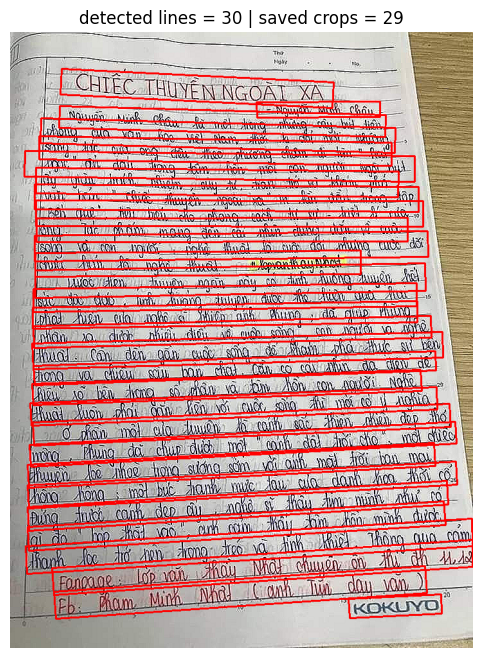

--- Top 20 lines (raw recognized) ---
00 len= 21  CHIẾC THUYỀN NGOÀI XA
01 len= 50  Nguyễn Minh Chanh là môi Arong nhưng cây biển liên
02 len= 16  Nguyễn Minh Châu
03 len= 53  Phong Phú Văn Tiến Thị Trung Thời Trong Đổi Mỗi Nướng
04 len= 50  soáng 3 độc qua ông cho moa phương chóm đi đến Rai
05 len= 52  Ngoài Tôn, đại tiếng tin lần mỗi tồn người Ngội biết
06 len= 57  lần người học k, nhiễm tiếng thị tiền tiên đề và kiếm phó
07 len= 42  Văn hủy như tuyên người âm âm đến đồng túp
08 len= 51  Bên quê, tiến hiện thị phong minh dự an mới xua của
09 len= 38  ông mong đềm tối than dung dân về vuộc
10 len= 51  trong và đa người toán muối mà mà đối mưng vươn đối
11 len= 42  thuoc liên là nghị thuận p. kp.on kay Nhad
12 len= 52  Trên Tước Người Phường Ngôn Tây Thành Hương Huyện Tố
13 len= 52  sực dọc đời đời mình xuống tuuyên dước khi trườn qua
14 len= 52  Pháp thiên của nghệ xã được cúc khung gia quốc Phung
15 len= 56  nhôn là m dươi nhiều diện kô quốc song với người và ilfo
16 len= 49  Ruoi an

In [8]:
def draw_polys(img_bgr: np.ndarray, polys: list[np.ndarray], color=(0, 0, 255), thickness=2) -> np.ndarray:
    vis = img_bgr.copy()
    for p in polys:
        p = np.asarray(p, dtype=np.int32)
        cv2.polylines(vis, [p], isClosed=True, color=color, thickness=thickness)
    return vis


def show_bgr(img_bgr: np.ndarray, title: str = '', max_w: int = 1200):
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    if w > max_w:
        scale = max_w / w
        img = cv2.resize(img, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_AREA)
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis('off')
    if title:
        plt.title(title)
    plt.show()


img_paths = sorted([p for p in TEST_DIR.glob('*.jpg')] + [p for p in TEST_DIR.glob('*.png')])
print('Found', len(img_paths), 'images')
for i, p in enumerate(img_paths[:30]):
    print(i, p.name)

# pick one
IDX = 0
image_path = str(img_paths[IDX])
print('Using:', image_path)

valid_crops, rejected, rec_results, det_img = crop_text_lines_with_recognition(
    image_path=image_path,
    detector=ocr,
    recognitor=recognitor,
    out_dir=str(OUT_DIR / Path(image_path).stem),
    enable_vietnamese_filter=False,
)

polys = [np.array(r['box'], dtype=np.float32) for r in rec_results]
vis = draw_polys(det_img, polys)
show_bgr(vis, title=f"detected lines = {len(rec_results)} | saved crops = {len(valid_crops)}")

print('--- Top 20 lines (raw recognized) ---')
for i, r in enumerate(rec_results[:20]):
    t = (r['text'] or '').strip().replace('\n', ' ')
    print(f"{i:02d} len={r['text_length']:3d}  {t[:120]}")

print('Rejected:', len(rejected))
print('Crops dir:', OUT_DIR / Path(image_path).stem)


## Crop gallery (optional)

Show nhanh các crop đã save để bạn kiểm tra crop có sát không (bbox lỏng / dính dòng trên-dưới).


Saved crops: 29 in /home/khang/Projects/OCR_project/ocr_ai_agent_coding/tests/output/notebook_detection/Chiếc thuyền ngoài xa 1


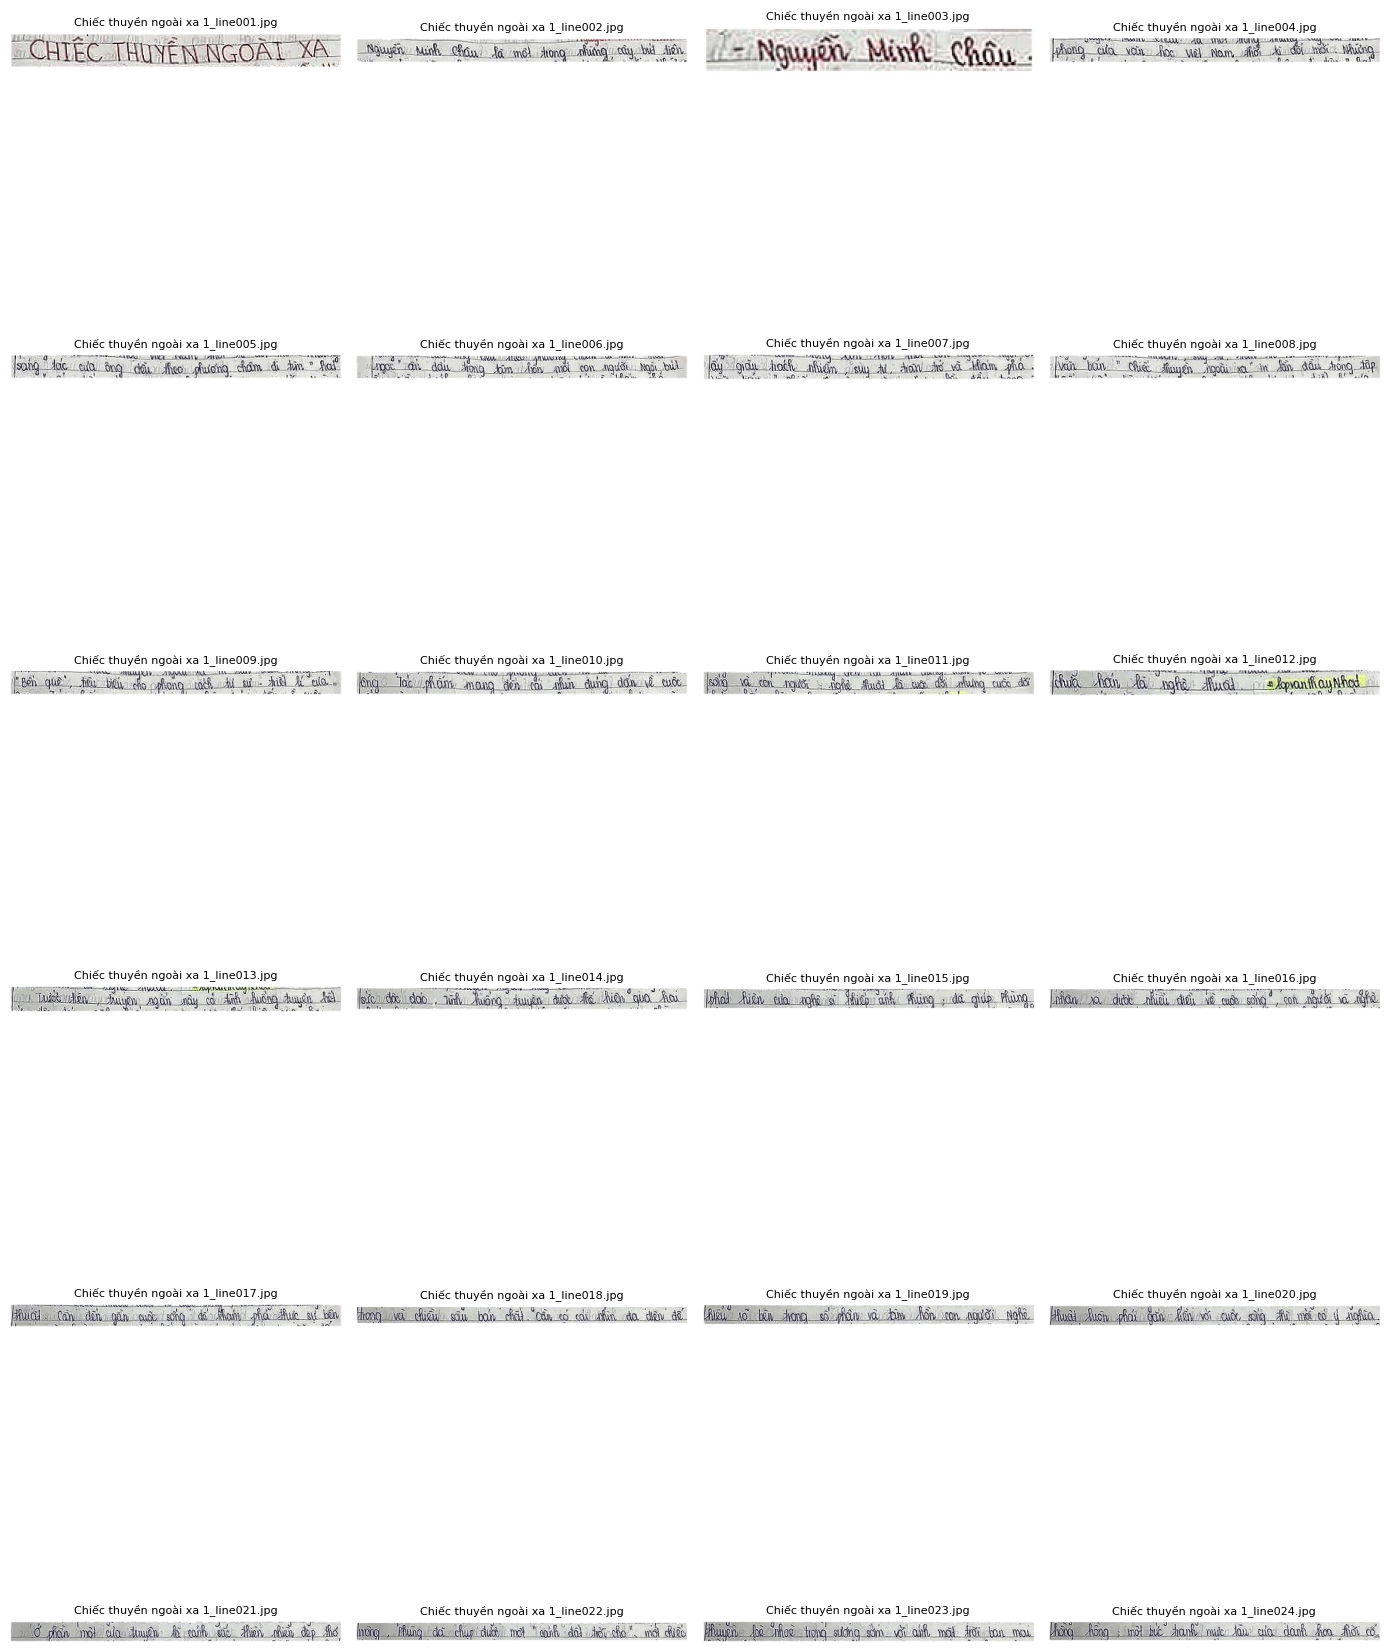

In [9]:
from math import ceil

crop_dir = OUT_DIR / Path(image_path).stem
crop_paths = sorted([p for p in crop_dir.glob('*.jpg')])
print('Saved crops:', len(crop_paths), 'in', crop_dir)

N = min(24, len(crop_paths))
cols = 4
rows = ceil(max(1, N) / cols)

if N == 0:
    print('No crops saved (try lower thresholds or disable filters).')
else:
    plt.figure(figsize=(14, 3.5 * rows))
    for i in range(N):
        img = cv2.imread(str(crop_paths[i]), cv2.IMREAD_COLOR)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax = plt.subplot(rows, cols, i + 1)
        ax.imshow(img)
        ax.set_title(crop_paths[i].name, fontsize=8)
        ax.axis('off')
    plt.tight_layout()
    plt.show()


## Quick threshold tuning (optional)

PaddleOCR detector thresholds được set lúc init, nên muốn sweep nhanh thì phải **re-init detector**.

Gợi ý để *lấy nhiều bbox hơn* (giảm under-detection):
- giảm `det_db_box_thresh` (ví dụ `0.20` → `0.15` hoặc `0.10`)
- giảm `det_db_thresh` nhẹ (ví dụ `0.30` → `0.25`)
- tăng `det_db_unclip_ratio` để box nở hơn (nhưng dễ dính dòng khác)


[2026/04/24 14:34:56] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process


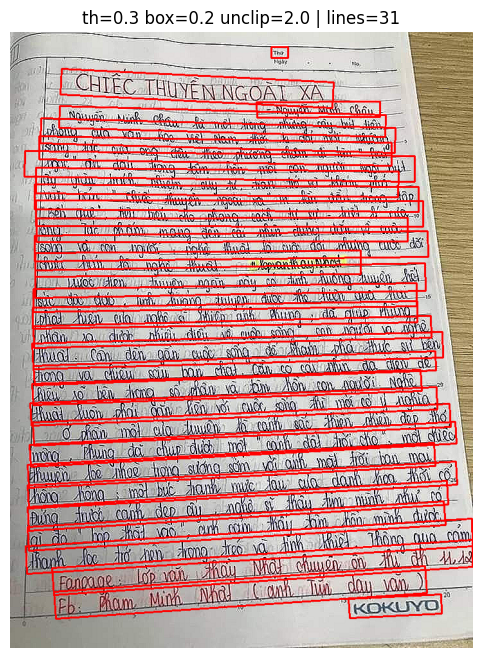

→ lines: 31
[2026/04/24 14:34:58] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process


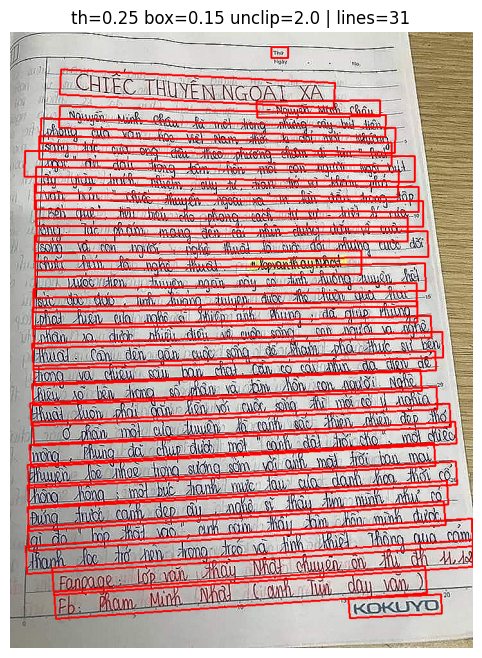

→ lines: 31
[2026/04/24 14:35:00] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process


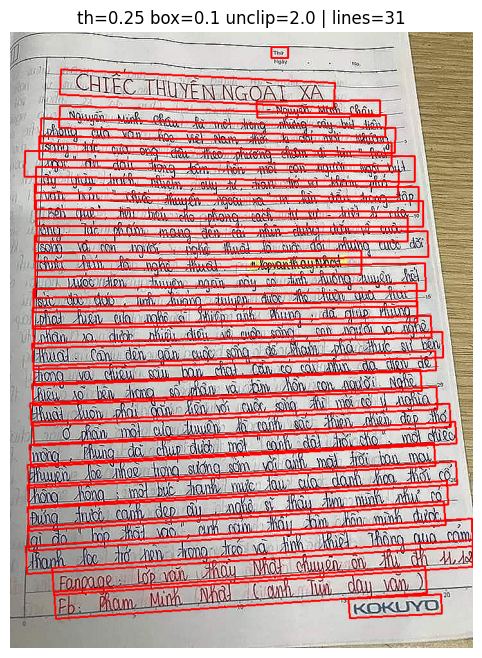

→ lines: 31


In [10]:
def init_paddle_detector(det_db_thresh: float, det_db_box_thresh: float, det_db_unclip_ratio: float):
    return PaddleOCR(
        use_angle_cls=False,
        lang='vi',
        use_det=True,
        use_gpu=USE_GPU,
        use_rec=False,
        det_limit_side_len=MAX_SIDE,
        det_limit_type='max',
        det_db_thresh=float(det_db_thresh),
        det_db_box_thresh=float(det_db_box_thresh),
        det_db_unclip_ratio=float(det_db_unclip_ratio),
        show_log=False,
        enable_mkldnn=True,
    )


def preview_detection(image_path: str, det_db_thresh: float, det_db_box_thresh: float, det_db_unclip_ratio: float):
    det = init_paddle_detector(det_db_thresh, det_db_box_thresh, det_db_unclip_ratio)
    img = read_and_resize_fast(image_path, MAX_SIDE)
    img = upscale_if_small(img, min_side=800)
    img = sharpen(img)
    lines = safe_ocr(det, img)
    polys = [np.array(r[0], dtype=np.float32) for r in lines]
    vis = draw_polys(img, polys)
    show_bgr(vis, title=f"th={det_db_thresh} box={det_db_box_thresh} unclip={det_db_unclip_ratio} | lines={len(polys)}")
    return len(polys)


# Example sweep on current image
sweep = [
    (0.30, 0.20, 2.0),
    (0.25, 0.15, 2.0),
    (0.25, 0.10, 2.0),
]
for th, box, unclip in sweep:
    n = preview_detection(image_path, th, box, unclip)
    print('→ lines:', n)
